# LABORATORIO Nº 1 - ALLENDE OLMEDO NICOLÁS

# Configuración inicial

In [1]:
# 📥 Instalación de librerías (ejecutar solo una vez)
!pip install ipywidgets librosa numpy matplotlib scipy
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# ⚙️ Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Entorno listo. Puede continuar con la Parte 1.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/s eta 0:00:00
✅ Entorno listo. Puede continuar con la Parte 1.


## La Señal ANALóGICA (Referencia)

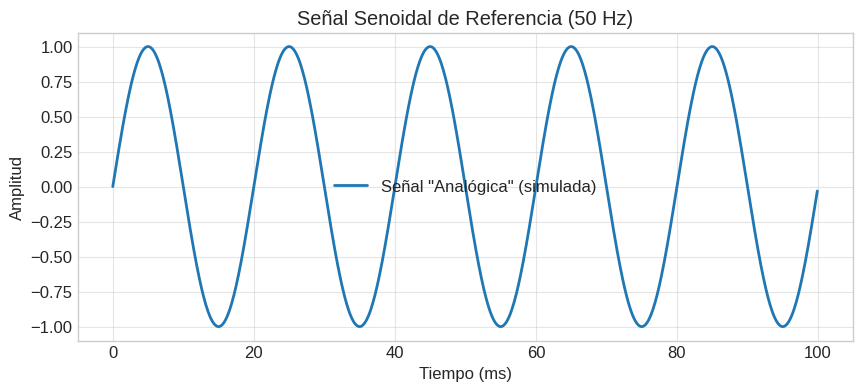

🔊 Reproduciendo señal de referencia...


In [12]:
# 📝 Parámetros de la señal
frecuencia_original = 50  # Hz (frecuencia de la onda)
duracion = 0.1            # segundos
fs_analogico = 10000      # Hz (muy alto para simular continuidad)

# 📐 Generar eje de tiempo
t = np.linspace(0, duracion, int(fs_analogico * duracion), endpoint=False)

# 🌊 Generar onda senoidal pura (señal analógica simulada)
senal_analogica = np.sin(2 * np.pi * frecuencia_original * t)

# 📊 Visualización
plt.figure(figsize=(10, 4))
plt.plot(t * 1000, senal_analogica, label='Señal "Analógica" (simulada)', linewidth=2)
plt.title('Señal Senoidal de Referencia (50 Hz)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# 🔊 Escuchar (opcional, requiere audio habilitado en el navegador)
print("🔊 Reproduciendo señal de referencia...")
display(Audio(senal_analogica, rate=fs_analogico))

##  Muestreo Interactivo (Sampling)

In [13]:
def visualizar_muestreo(fs_muestreo):
    """Función que muestrea la señal y compara con la referencia"""
    # Generar tiempos de muestreo
    t_muestreo = np.arange(0, duracion, 1/fs_muestreo)

    # Tomar muestras de la señal analógica
    muestras = np.sin(2 * np.pi * frecuencia_original * t_muestreo)

    # Gráfico comparativo
    plt.figure(figsize=(10, 4))
    plt.plot(t * 1000, senal_analogica, 'gray', alpha=0.5, label='Señal original')
    plt.stem(t_muestreo * 1000, muestras, linefmt='b-', markerfmt='bo', basefmt='k-',
label='Muestras tomadas')
    plt.title(f'Muestreo a {fs_muestreo} Hz')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Explicación pedagógica
    if fs_muestreo < 2 * frecuencia_original:
        print("⚠️ ATENCIÓN: fs < 2×f. Estás por debajo del límite de Nyquist. ¡Aparecerá aliasing!")
    else:
        print("✅ Buen muestreo. La frecuencia de muestreo cumple Nyquist (fs ≥ 2×f).")

# 🎛️ Control interactivo
print("🎛️ Use el deslizador para cambiar la frecuencia de muestreo (50 Hz a 200 Hz)")
interact(visualizar_muestreo, fs_muestreo=widgets.IntSlider(min=50, max=300, step=10,
value=100, description='fs (Hz):'));

🎛️ Use el deslizador para cambiar la frecuencia de muestreo (50 Hz a 200 Hz)


interactive(children=(IntSlider(value=100, description='fs (Hz):', max=300, min=50, step=10), Output()), _dom_…

### 1) La Frecuencia de Muestreo en 100 Hz, mantiene sobre la línea media ubicada en el rango de Amplitud de 0 (cero). Nos da como resultado un "Buen muestreo" ya que la frecuencia de muestreoi cumple con Nyquist (fs >= 2xf).

### 2) En caso de bajar la freceuncia e muestreo a 60 Hz, no se respeta correctamente la onda. Nos da como resultado "alisasing", ya que la frecuencia se encuantra por debajo del límite de Nyquist (fs < 2xf). La muestra no es sufuiciente para reconstruir la con presición la señal original.

### 3) En caso de 200 Hz la frecuencia de muestreo cumple con Nyquist (fs >= 2xf), esto nos sugiere un mejor fidelidad de la muestra, ya que se están tomando suficientes muestras para reconstruir con precisión la señal original. Lo que garantiza que no habrá "aliasing" y que la señal muestreada representará fielmente la señal analógica original.

## Cuantización interactiva

In [14]:
def cuantizar_senal(bits):
    """Aplica cuantización de 'bits' a la señal muestreada y la visualiza"""
    # Muestreamos primero a una tasa segura
    fs_seguro = 1000
    t_seguro = np.arange(0, duracion, 1/fs_seguro)
    senal_muestreada = np.sin(2 * np.pi * frecuencia_original * t_seguro)

    # Fórmula de cuantización simétrica (normalizada entre -1 y 1)
    niveles = 2**bits
    señal_cuantizada = np.round(senal_muestreada * (niveles/2 - 1)) / (niveles/2 - 1)

    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(t_seguro * 1000, senal_muestreada, 'gray', alpha=0.6, label='Señal muestreada (continua)')
    plt.plot(t_seguro * 1000, señal_cuantizada, 'r-', linewidth=2, label=f'Cuantizada ({bits} bits)')
    plt.title(f'Cuantización: {bits} bits → {niveles} niveles posibles')
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud cuantizada')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Explicación
    print(f"📊 Con {bits} bits tenemos {niveles} niveles. "
          f"El 'escalado' visible es el ruido de cuantización.")

# 🎛️ Control interactivo
print("🎛️ Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud")
interact(cuantizar_senal, bits=widgets.IntSlider(min=2, max=8, step=1, value=4,
description='Bits:'));

🎛️ Ajuste la profundidad de bits para ver el efecto en la precisión de amplitud


interactive(children=(IntSlider(value=4, description='Bits:', max=8, min=2), Output()), _dom_classes=('widget-…

##  Aliasing (Solapamiento Frecuencial)

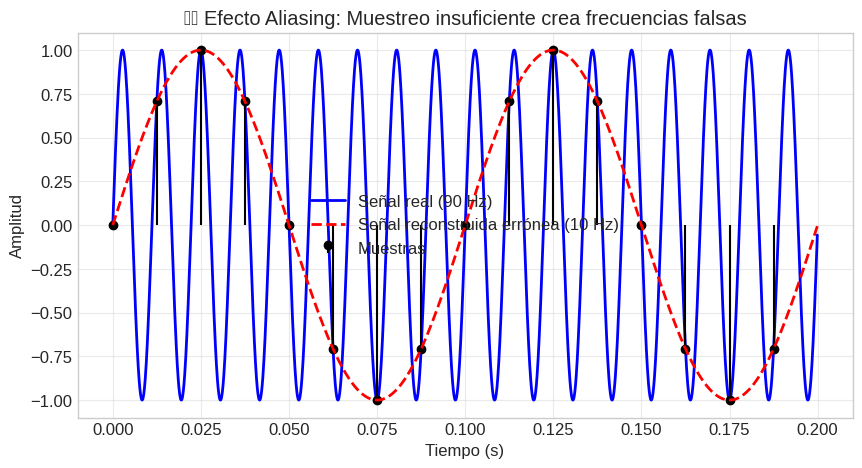

📌 Teorema de Nyquist: fs debe ser ≥ 180 Hz para 90 Hz.
📌 Usamos fs = 80 Hz → ¡INFERIOR AL LÍMITE!
📌 Resultado: El cerebro/computadora interpreta una onda de 10 Hz.


In [19]:
def demostrar_aliasing():
    """Compara señal original, muestreo insuficiente y reconstrucción errónea"""
    # Frecuencias
    f_alta = 90   # Hz (señal real)
    fs_baja = 80  # Hz (frecuencia de muestreo)

    # Tiempos
    t = np.linspace(0, 0.2, 2000, endpoint=False)
    t_muestreo = np.arange(0, 0.2, 1/fs_baja)

    # Señales
    senal_real = np.sin(2 * np.pi * f_alta * t)
    muestras = np.sin(2 * np.pi * f_alta * t_muestreo)

    # Frecuencia que "percibimos" al reconstruir mal (alias)
    f_alias = abs(f_alta - fs_baja)  # 70 - 80 = 10 Hz (en valor absoluto)
    senal_alias = np.sin(2 * np.pi * f_alias * t)

    # Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(t, senal_real, 'b', linewidth=2, label=f'Señal real ({f_alta} Hz)')
    plt.stem(t_muestreo, muestras, linefmt='k-', markerfmt='ko', basefmt=' ',
label='Muestras')
    plt.plot(t, senal_alias, 'r--', linewidth=2, label=f'Señal reconstruida errónea ({f_alias} Hz)')
    plt.title('⚠️ Efecto Aliasing: Muestreo insuficiente crea frecuencias falsas')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

    print(f"📌 Teorema de Nyquist: fs debe ser ≥ {2*f_alta} Hz para {f_alta} Hz.")
    print(f"📌 Usamos fs = {fs_baja} Hz → ¡INFERIOR AL LÍMITE!")
    print(f"📌 Resultado: El cerebro/computadora interpreta una onda de {f_alias} Hz.")

demostrar_aliasing()

##  Dominio del Tiempo vs. Dominio de la Frecuencia

🔍 Observe los picos en 50 Hz y 150 Hz. La FFT descompone la señal en sus 'notas' individuales.


/tmp/ipykernel_18888/1335942582.py:39: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18888/1335942582.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()


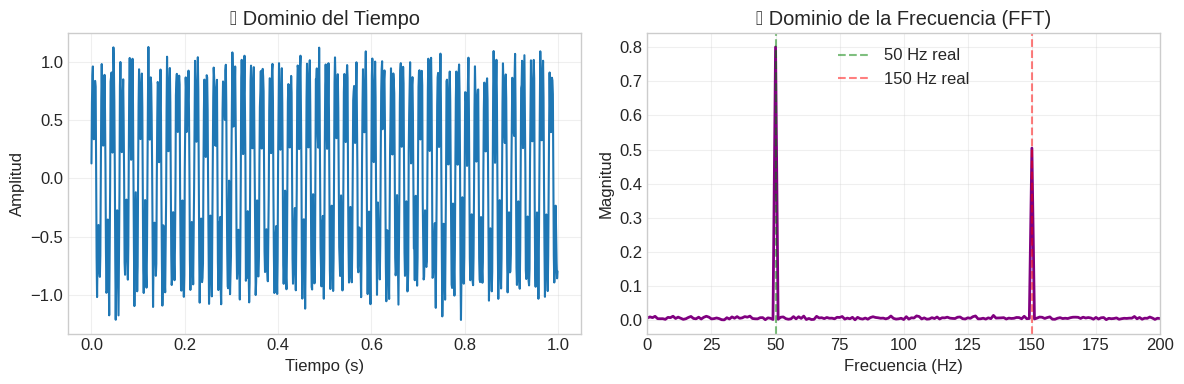

In [22]:
def analisis_fourier_simple():
    """Genera una señal compuesta y muestra su espectro de frecuencias"""
    fs = 1000
    t = np.linspace(0, 1, fs, endpoint=False)

    # Señal compuesta: 50 Hz + 150 Hz + ruido leve
    senal = 0.8 * np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 150 * t) + 0.1 * np.random.randn(len(t))

    # 🔄 Transformada Rápida de Fourier (FFT)
    espectro = np.fft.fft(senal)
    frecuencias = np.fft.fftfreq(len(senal), d=1/fs)

    # Tomamos solo la mitad positiva (el espectro es simétrico)
    idx_pos = frecuencias >= 0
    f_pos = frecuencias[idx_pos]
    amp_pos = np.abs(espectro[idx_pos]) * 2 / len(senal)  # Normalización

    # Gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Dominio del tiempo
    ax1.plot(t, senal, linewidth=1.5)
    ax1.set_title('📈 Dominio del Tiempo')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)

    # Dominio de la frecuencia
    ax2.plot(f_pos, amp_pos, color='purple', linewidth=2)
    ax2.set_title('📊 Dominio de la Frecuencia (FFT)')
    ax2.set_xlabel('Frecuencia (Hz)')
    ax2.set_ylabel('Magnitud')
    ax2.set_xlim(0, 200)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(50, color='g', linestyle='--', alpha=0.5, label='50 Hz real')
    ax2.axvline(150, color='r', linestyle='--', alpha=0.5, label='150 Hz real')
    ax2.legend()

    plt.tight_layout()

    plt.show()
print("🔍 Observe los picos en 50 Hz y 150 Hz. La FFT descompone la señal en sus 'notas' individuales.")
analisis_fourier_simple()

# **RESPUESTAS ACTIVIDAD LABOATORIO Nº 1**

## CONSIGNA 1. -> Muestreo: Si graba un tono puro de 300 Hz, ¿cuál es la frecuencia de muestreo mínima teórica para evitar aliasing? ¿Por qué en la práctica se usa un valor mayor?

**La frecuencia mínima de muestreo teórica es de 600 Hz**. A partir de ésta frecuencia comienzan a aparecer alertas de "alaising". El teorema establece que para evitar el aliasing (falsas frecuencias bajas), la tasa de muestreo (Fs) debe ser al menos el doble de la frecuencia máxima de la señal (F max) (Frecuencia de Nyquist). Para permitir el uso de filtros analógicos no ideales, evitar distorsiones y facilitar el procesamiento de señales


**Filtros no ideales**: En el mundo real, los filtros no cortan de golpe la frecuencia por encima de la de Nyquist. Se necesita una "banda de transición" (espacio extra) para que el filtro funcione sin afectar el audio deseado.
**Aliasing**: Un muestreo insuficiente provoca que frecuencias altas se reflejen y aparezcan como frecuencias bajas erróneas en el espectro.
**Facilidad de reconstrucción**: Tasas más altas facilitan la conversión de digital a analógico y reducen el error de cuantificación.

## CONSIGNA 2. -> Cuantización: Un audio de estudio se graba a 24 bits y 48 kHz. Otro archivo comprimido para web usa 8 bits y 22 kHz. Describa dos diferencias auditivas y visuales que esperaría encontrar entre ambos.

DIFERENCIAS AUDITIVAS:

Calidad del Sonido y Ruido: El audio de estudio (24 bits) tendrá un rango dinámico mucho mayor y una resolución de amplitud significativamente más alta. Esto significa que los sonidos muy suaves y los muy fuertes se representarán con mucha más precisión, resultando en un sonido más limpio, con menos ruido de cuantización perceptible. El archivo para web (8 bits) tendrá un rango dinámico limitado, lo que puede llevar a que los detalles sutiles se pierdan y se perciba un ruido de cuantización (un zumbido o siseo de bajo nivel) más evidente, especialmente en pasajes silenciosos o al aumentar el volumen.
Respuesta en Frecuencia y Claridad: El audio de estudio (48 kHz) podrá reproducir frecuencias hasta 24 kHz (mitad de la frecuencia de muestreo, por Nyquist). Esto es superior al límite del oído humano (aproximadamente 20 kHz), asegurando que todas las frecuencias audibles estén presentes y que la señal suene completa y brillante. El archivo para web (22 kHz) solo podrá reproducir frecuencias hasta 11 kHz. Esto significa que muchas de las frecuencias más altas que aportan "aire" y "claridad" al sonido (como armónicos de instrumentos o sibilantes en voces) estarán ausentes, haciendo que el audio suene más opaco, menos detallado y con una pérdida perceptible de "brillo".

DIFERENCIAS VISUALES:

Forma de Onda (Amplitud): Al visualizar la forma de onda en el dominio del tiempo, el archivo de 24 bits mostrará transiciones de amplitud mucho más suaves y finas, con un mayor detalle en los picos y valles de la onda. En contraste, el archivo de 8 bits mostrará una forma de onda con escalones más evidentes y gruesos, especialmente en las partes de baja amplitud, debido a la menor cantidad de niveles de cuantificación disponibles. Esto es lo que se conoce como "escalonamiento" o "ruido de cuantización" y se vería como bloques discretos en la amplitud.

## CONSIGNA 3. -> Aliasing: En el código de la Parte 4, cambie f_alta = 90 y fs_baja = 80. Ejecute mentalmente o en código: ¿qué frecuencia "falsa" aparecerá? Explique el cálculo.

La frecuencia "falsa" se calcula utilizando la fórmula del aliasing, que es el valor absoluto de la diferencia entre la frecuencia de la señal real y la frecuencia de muestreo cuando esta última es insuficiente. Por lo tanto, la frecuencia "falsa" que el sistema interpretará erróneamente será de 10 Hz.

El Teorema de Nyquist establece que la frecuencia de muestreo (fs) debe ser al menos el doble de la frecuencia máxima (f_max) de la señal para evitar el aliasing. En este caso, la señal real es de 90 Hz, por lo que la frecuencia de muestreo mínima requerida sería 2 * 90 Hz = 180 Hz. Al utilizar una frecuencia de muestreo de 80 Hz (que es inferior a 180 Hz), se produce aliasing. La señal original de 90 Hz se "refleja" en el espectro de frecuencias muestreadas, apareciendo como una frecuencia diferente, que se calcula como la diferencia absoluta entre la frecuencia de la señal y la frecuencia de muestreo (o un múltiplo de ella si hay más reflexiones, pero en el caso más simple es la diferencia directa cuando fs < f_alta pero fs es cercana a f_alta).

## CONSIGNA 3. -> Dominios: Si aplica la FFT a un archivo .wav de voz humana y observa un pico dominante en 220 Hz, ¿qué información le da esto sobre la señal original? ¿Podría distinguirse de un silbido de 220 Hz solo con este pico?

Un pico dominante en 220 Hz en la Transformada Rápida de Fourier (FFT) de una señal de voz humana generalmente indica la **frecuencia fundamental (F0)** de la voz. La frecuencia fundamental *es la frecuencia más baja producida por la vibración de las cuerdas vocales, y es lo que nuestro oído interpreta como el tono o la altura de la voz.*

**Tono/Altura (Pitch):** Un F0 de 220 Hz sugiere que la persona que habla tiene una voz en un rango relativamente alto. En adultos, las voces masculinas suelen tener un F0 entre 85 y 180 Hz, mientras que las voces femeninas están entre 165 y 255 Hz. Por lo tanto, 220 Hz podría ser una voz femenina o una voz masculina más alta (tenor, por ejemplo), o incluso una voz infantil.

**Voz Sonora:** La presencia de un pico fundamental claro indica que la señal es una voz sonora (es decir, vocalizada, a diferencia de sonidos sin voz como 's' o 'f').
¿Podría distinguirse de un silbido de 220 Hz solo con este pico?

**No, solo con un pico dominante de 220 Hz, sería muy difícil distinguir una voz humana de un silbido puro de 220 Hz.** Por las siguientes razones:

**Armónicos y Formantes** (Voz Humana): La voz humana es un sonido complejo. Además de la frecuencia fundamental (el pico de 220 Hz), la vibración de las cuerdas vocales produce una serie de frecuencias armónicas (múltiplos enteros de F0, como 440 Hz, 660 Hz, 880 Hz, etc.), aunque con amplitudes decrecientes. Además, la cavidad vocal (boca, faringe, nariz) actúa como un resonador, creando picos de energía adicionales en ciertas bandas de frecuencia llamadas formantes. Estos armónicos y formantes son cruciales para la inteligibilidad y la percepción del timbre de la voz (la 'calidad' única de cada voz y cada vocal).

**Silbido Puro (Tono Puro)**: Un silbido puro o un tono generado electrónicamente a 220 Hz es, idealmente, una onda senoidal. En su espectro FFT, mostraría un único pico muy prominente en 220 Hz y muy poco o ningún contenido en otras frecuencias (a menos que haya armónicos generados por la forma en que se produce el silbido o distorsiones).